In [74]:
print("all ok")

all ok


In [75]:
import sys, os

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
sys.path.append(project_root)

print("Project root added to path:", project_root)

Project root added to path: d:\gen ai projects\langchain and its projects\automated-research-report-generation


In [76]:
from research_and_analyst.utils.model_loader import ModelLoader

In [77]:
from langgraph.graph import StateGraph,START,END
from langchain_core.messages import AIMessage,HumanMessage,SystemMessage
from langgraph.checkpoint.memory import MemorySaver

In [78]:
model_loader = ModelLoader()

{"timestamp": "2026-04-10T10:20:02.653165Z", "level": "info", "event": "Initializing ApiKeyManager"}
{"timestamp": "2026-04-10T10:20:02.654171Z", "level": "info", "event": "OPENAI_API_KEY loaded successfully from environment"}
{"timestamp": "2026-04-10T10:20:02.655473Z", "level": "info", "event": "GOOGLE_API_KEY loaded successfully from environment"}
{"timestamp": "2026-04-10T10:20:02.656466Z", "level": "info", "event": "GROQ_API_KEY loaded successfully from environment"}
{"path": "D:\\gen ai projects\\langchain and its projects\\automated-research-report-generation\\research_and_analyst\\config\\configuration.yaml", "keys": ["astra_db", "embedding_model", "retriever", "llm"], "timestamp": "2026-04-10T10:20:02.662414Z", "level": "info", "event": "Configuration loaded successfully"}
{"config_keys": ["astra_db", "embedding_model", "retriever", "llm"], "timestamp": "2026-04-10T10:20:02.663509Z", "level": "info", "event": "YAML configuration loaded successfully"}


In [79]:
llm = model_loader.load_llm()

{"provider": "openai", "model": "gpt-4o", "timestamp": "2026-04-10T10:20:03.459185Z", "level": "info", "event": "Loading LLM"}
{"provider": "openai", "model": "gpt-4o", "timestamp": "2026-04-10T10:20:03.463231Z", "level": "info", "event": "LLM loaded successfully"}


In [80]:
llm.invoke("hi").content

HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


'Hello! How can I assist you today?'

In [81]:
from typing import List
from typing_extensions import TypedDict
from pydantic import BaseModel, Field

In [82]:
class Analyst(BaseModel):
    name: str = Field(description="Name of the analyst.")
    role: str = Field(description="Role of the analyst in the context of the topic.")
    affiliation: str = Field(description="Primary affiliation of the analyst.")
    description: str = Field(description="Description of the analyst focus, concerns, and motives.")
    
    @property
    def persona(self) -> str:
        return f"Name: {self.name}\nRole: {self.role}\nAffiliation: {self.affiliation}\nDescription: {self.description}\n"
    

In [83]:
analyst = Analyst(
    name="vikas jangid",
    role="genai eng",
    affiliation="AI research Lab",
    description="I am a genai eng as well as mentor"
)

In [84]:
print(analyst.name)

vikas jangid


In [85]:
print(analyst.persona)

Name: vikas jangid
Role: genai eng
Affiliation: AI research Lab
Description: I am a genai eng as well as mentor



In [86]:

class Perspectives(BaseModel):
       analysts: List[Analyst] = Field(description="Comprehensive list of analysts with their roles and affiliations.")

In [87]:
class GenerateAnalystState(TypedDict):
    topic: str
    max_analysts: int
    human_analyst_feedback: str
    analysts: List[Analyst]

In [88]:

Analyst(
        name="Dr. Neha Patel",
        role="Medical Data Scientist",
        affiliation="Stanford Medicine",
        description="Focuses on predictive models for patient outcomes."
    ),

(Analyst(name='Dr. Neha Patel', role='Medical Data Scientist', affiliation='Stanford Medicine', description='Focuses on predictive models for patient outcomes.'),)

In [89]:
analyst_instructions="""You are tasked with creating a set of AI analyst personas. Follow these instructions carefully:

1. First, review the research topic:
{topic}
        
2. Examine any editorial feedback that has been optionally provided to guide creation of the analysts: 
        
{human_analyst_feedback}
    
3. Determine the most interesting themes based upon documents and / or feedback above.
                    
4. Pick the top {max_analysts} themes.

5. Assign one analyst to each theme."""

In [90]:
def create_analyst(state: GenerateAnalystState):
    """it is creating my analyst"""
    topic = state["topic"]
    max_analysts = state["max_analysts"]
    human_analyst_feedback = state.get("human_analyst_feedback","")

    structured_llm=llm.with_structured_output(Perspectives)

    system_message=analyst_instructions.format(topic=topic,
                                max_analysts=max_analysts,
                                human_analyst_feedback=human_analyst_feedback)
    
    analysts=structured_llm.invoke([SystemMessage(content=system_message)]+[HumanMessage(content="Generate the set of analysts")])

    return {"analysts": analysts.analysts}




In [91]:
create_analyst(
    {'topic': 'health',
    'max_analysts': 2,
    'human_analyst_feedback': 'give the real info'}
    )

HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


{'analysts': [Analyst(name='Dr. Emily Chen', role='Public Health Researcher', affiliation='World Health Organization', description='Dr. Emily Chen focuses on global health trends and the impact of public health policies on population health outcomes. Her primary concern is understanding how different health interventions can be optimized to improve health equity and access to care across diverse populations. She is motivated by the need to address health disparities and promote sustainable health practices worldwide.'),
  Analyst(name='Dr. Raj Patel', role='Healthcare Technology Analyst', affiliation='HealthTech Innovations', description='Dr. Raj Patel specializes in the intersection of healthcare and technology, analyzing how digital health tools and innovations can transform patient care and healthcare delivery. His focus is on evaluating the effectiveness and integration of telemedicine, wearable health devices, and AI-driven diagnostics in improving patient outcomes. He is driven b

In [92]:
def human_feedback(state):
    """no output node that should be intrupted on"""
    pass

In [93]:
def should_continue(state):
    """Return the next node to execute"""
    human_analyst_feedback = state.get("human_analyst_feedback", None)
    if human_analyst_feedback:
        return "create_analyst"

In [94]:
from IPython.display import Image, display

In [95]:
builder=StateGraph(GenerateAnalystState)

In [96]:
builder.add_node("create_analyst",create_analyst)
builder.add_node("human_feedback",human_feedback)


In [97]:
# builder.add_node("should_continue",should_continue)

In [98]:
builder.add_edge(START,"create_analyst")
builder.add_edge("create_analyst","human_feedback")
builder.add_conditional_edges("human_feedback",
                          should_continue,
                          ["create_analyst",
                           END])

In [99]:
memory = MemorySaver()

In [100]:
graph=builder.compile(interrupt_before=["human_feedback"], checkpointer=memory)

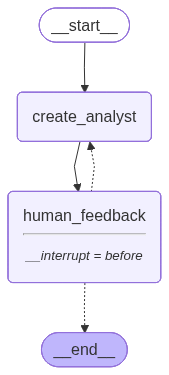

In [101]:
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [102]:
topic = "the benifits of adopting langgraph as an agent framework"


In [103]:
max_analysts = 4

In [104]:
thread = {"configurable":{"thread_id":1}}

In [105]:
for event in graph.stream({"topic":topic,
              "max_analysts":max_analysts},
             thread,
             stream_mode= "values"):
    analysts = event.get('analysts', '')
    
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50)  

HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


Name: Dr. Emily Chen
Affiliation: Institute of Advanced AI Systems
Role: AI Framework Researcher
Description: Dr. Chen focuses on the comparative analysis of AI frameworks, with a particular interest in how LangGraph enhances agent-based modeling. Her research aims to identify the unique benefits LangGraph offers in terms of scalability and flexibility compared to traditional frameworks.
--------------------------------------------------
Name: Raj Patel
Affiliation: Tech Innovations Inc.
Role: Software Developer
Description: Raj is a software developer specializing in AI applications. He is interested in the practical implementation of LangGraph in real-world projects, particularly how it can streamline development processes and improve the efficiency of AI agents.
--------------------------------------------------
Name: Lisa Gomez
Affiliation: FutureTech Consulting
Role: Business Strategist
Description: Lisa analyzes the strategic advantages of adopting new technologies in business. S

In [106]:
state=graph.get_state(thread)
state

StateSnapshot(values={'topic': 'the benifits of adopting langgraph as an agent framework', 'max_analysts': 4, 'analysts': [Analyst(name='Dr. Emily Chen', role='AI Framework Researcher', affiliation='Institute of Advanced AI Systems', description='Dr. Chen focuses on the comparative analysis of AI frameworks, with a particular interest in how LangGraph enhances agent-based modeling. Her research aims to identify the unique benefits LangGraph offers in terms of scalability and flexibility compared to traditional frameworks.'), Analyst(name='Raj Patel', role='Software Developer', affiliation='Tech Innovations Inc.', description='Raj is a software developer specializing in AI applications. He is interested in the practical implementation of LangGraph in real-world projects, particularly how it can streamline development processes and improve the efficiency of AI agents.'), Analyst(name='Lisa Gomez', role='Business Strategist', affiliation='FutureTech Consulting', description='Lisa analyzes

In [107]:
state.next

('human_feedback',)

In [108]:
graph.update_state(thread,
                   {"human_analyst_feedback":"add something from the startup perspective and focus on the latest enterprise application"}, as_node="human_feedback")

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f134c6f-4dc1-6570-8002-83200a7f2531'}}

In [109]:
for event in graph.stream({"topic":topic,
              "max_analysts":max_analysts},
             thread,
             stream_mode= "values"):
    analysts = event.get('analysts', '')
    
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50)  

Name: Dr. Emily Chen
Affiliation: Institute of Advanced AI Systems
Role: AI Framework Researcher
Description: Dr. Chen focuses on the comparative analysis of AI frameworks, with a particular interest in how LangGraph enhances agent-based modeling. Her research aims to identify the unique benefits LangGraph offers in terms of scalability and flexibility compared to traditional frameworks.
--------------------------------------------------
Name: Raj Patel
Affiliation: Tech Innovations Inc.
Role: Software Developer
Description: Raj is a software developer specializing in AI applications. He is interested in the practical implementation of LangGraph in real-world projects, particularly how it can streamline development processes and improve the efficiency of AI agents.
--------------------------------------------------
Name: Lisa Gomez
Affiliation: FutureTech Consulting
Role: Business Strategist
Description: Lisa analyzes the strategic advantages of adopting new technologies in business. S

HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


Name: Dr. Emily Chen
Affiliation: Global Tech Solutions
Role: Enterprise Technology Strategist
Description: Dr. Chen focuses on the integration of innovative technologies within large enterprises. She is particularly interested in how adopting LangGraph as an agent framework can streamline operations, enhance data processing capabilities, and improve decision-making processes in complex organizational structures.
--------------------------------------------------
Name: Raj Patel
Affiliation: Innovate Ventures
Role: Startup Ecosystem Analyst
Description: Raj Patel analyzes emerging technologies from a startup perspective. He is keen on exploring how LangGraph can provide startups with a competitive edge by enabling rapid development and deployment of intelligent agents, thus reducing time-to-market and operational costs.
--------------------------------------------------
Name: Sophia Martinez
Affiliation: AI Ethics Consortium
Role: AI Ethics and Compliance Expert
Description: Sophia Mar

In [110]:
further_feedback = "None"
graph.update_state(thread, {"human_analyst_feedback":further_feedback}, as_node="human_feedback")

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f134c6f-8d56-6e86-8006-f499b4744725'}}

### second workflow

In [111]:
from dotenv import load_dotenv
load_dotenv()

True

In [112]:
import os
tavily_api_key=os.getenv("TAVILY_API_KEY")

In [113]:
from langchain_community.tools.tavily_search import TavilySearchResults

In [114]:
tavily_search=TavilySearchResults(tavily_api_key=tavily_api_key)

In [115]:
tavily_search.invoke("langgraph")

[{'title': 'LangGraph: What It Is and How To Use It [Tutorial] - Lazy Programmer',
  'url': 'https://lazyprogrammer.me/langgraph/',
  'content': '## What is LangGraph?\n\nLangGraph is a framework for building agentic and multi-agent applications. What does that mean? Simply put, it’s a tool to help you create AI agents that can tackle everyday tasks at work—whether it’s answering emails, managing schedules, or analyzing data.\n\nHere’s why it’s special:\n\n## How Does LangGraph Handle Complex Workflows With Multiple Agents?\n\nLangGraph uses machine learning principles to handle complex workflows by enabling multiple AI agents to work together effectively. Its graph-based architecture organizes tasks into a flow, with each agent acting as a node in the graph. This structure, similar to how layers in a neural network operate, ensures modularity and scalability. [...] ## Can LangGraph Integrate With Other Tools and Platforms?\n\nYes, LangGraph is designed to seamlessly integrate with a v

In [116]:
from langchain_community.document_loaders import WikipediaLoader

docs = WikipediaLoader("LangGraph").load()
print(docs[0].page_content[:500])

KeyboardInterrupt: 

In [135]:
import operator
from typing import Annotated
from langgraph.graph import MessagesState


class InterviewState(MessagesState):
    max_num_turns: int
    context: Annotated[list, operator.add]
    analyst:Analyst
    interview:str
    sections: list

class SearchQuery(BaseModel):
    search_query: str= Field(None, description="Search quesry for retrieval")

In [136]:
question_instructions = """You are an analyst tasked with interviewing an expert to learn about a specific topic. 

Your goal is boil down to interesting and specific insights related to your topic.

1. Interesting: Insights that people will find surprising or non-obvious.
        
2. Specific: Insights that avoid generalities and include specific examples from the expert.

Here is your topic of focus and set of goals: {goals}
        
Begin by introducing yourself using a name that fits your persona, and then ask your question.

Continue to ask questions to drill down and refine your understanding of the topic.
        
When you are satisfied with your understanding, complete the interview with: "Thank you so much for your help!"

Remember to stay in character throughout your response, reflecting the persona and goals provided to you."""

In [137]:
def generate_question(state: InterviewState):
    """Node to generate questions"""
    analyst=state["analyst"]
    messages=state["messages"]
    system_message=question_instructions.format(goals=analyst.persona)
    question=llm.invoke([SystemMessage(content=system_message)]+messages)
    return {"messages":[question]}

In [138]:
from langchain_core.messages import get_buffer_string

In [139]:
search_instructions = SystemMessage(content=f"""You will be given a conversation between an analyst and an expert. 
Your goal is to generate a well-structured query for use in retrieval and / or web-search related to the conversation. 
First, analyze the full conversation.
Pay particular attention to the final question posed by the analyst.
Convert this final question into a well-structured web search query""")

In [140]:
def search_web(state: InterviewState):
    """Retrieve data from web"""
    structure_llm=llm.with_structured_output(SearchQuery)
    search_query=structure_llm.invoke([search_instructions]+state["messages"])

    search_docs = tavily_search.invoke(search_query.search_query)

    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document href="{doc["url"]}"/>\n{doc["content"]}\n</Document>'
            for doc in search_docs
        ]
    )

    return {"context": [formatted_search_docs]}

In [141]:
def search_wikipedia(state:InterviewState):
    """
    Retrieve data from wiki
    """
    # Search query
    structured_llm = llm.with_structured_output(SearchQuery)
    search_query = structured_llm.invoke([search_instructions]+state['messages'])
    
    print("*******************************")
    print(search_query)
    
    # Search
    search_docs = WikipediaLoader(query=search_query.search_query).load()

     # Format
    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document source="{doc.metadata["source"]}" page="{doc.metadata.get("page", "")}"/>\n{doc.page_content}\n</Document>'
            for doc in search_docs
        ]
    )

    return {"context": [formatted_search_docs]} 

In [142]:
answer_instructions = """You are an expert being interviewed by an analyst.

Here is analyst area of focus: {goals}. 
        
You goal is to answer a question posed by the interviewer.

To answer question, use this context:
        
{context}

When answering questions, follow these guidelines:
        
1. Use only the information provided in the context. 
        
2. Do not introduce external information or make assumptions beyond what is explicitly stated in the context.

3. The context contain sources at the topic of each individual document.

4. Include these sources your answer next to any relevant statements. For example, for source # 1 use [1]. 

5. List your sources in order at the bottom of your answer. [1] Source 1, [2] Source 2, etc
        
6. If the source is: <Document source="assistant/docs/llama3_1.pdf" page="7"/>' then just list: 
        
[1] assistant/docs/llama3_1.pdf, page 7 
        
And skip the addition of the brackets as well as the Document source preamble in your citation."""

In [143]:
def generate_answer(state:InterviewState):
   
    """ Node to answer a question """

    # Get state
    analyst = state["analyst"]
    messages = state["messages"]
    context = state["context"]

    # Answer question
    system_message = answer_instructions.format(goals=analyst.persona, context=context)
    answer = llm.invoke([SystemMessage(content=system_message)]+messages)
            
    # Name the message as coming from the expert
    answer.name = "expert"
    
    # Append it to state
    return {"messages": [answer]}

In [144]:
def route_messages(state: InterviewState, 
                   name: str = "expert"):

    """ Route between question and answer """
    
    # Get messages
    messages = state["messages"]
    max_num_turns = state.get('max_num_turns',2)

    # Check the number of expert answers 
    num_responses = len(
        [m for m in messages if isinstance(m, AIMessage) and m.name == name]
    )

    # End if expert has answered more than the max turns
    if num_responses >= max_num_turns:
        return 'save_interview'

    # This router is run after each question - answer pair 
    # Get the last question asked to check if it signals the end of discussion
    last_question = messages[-2]
    
    if "Thank you so much for your help" in last_question.content:
        return 'save_interview'
    
    return "ask_question"

In [145]:
def save_interview(state: InterviewState):
    
    """ Save interviews """

    # Get messages
    messages = state["messages"]
    
    # Convert interview to a string
    interview = get_buffer_string(messages)
    
    # Save to interviews key
    return {"interview": interview}

In [146]:
section_writer_instructions = """You are an expert technical writer. 
            
Your task is to create a short, easily digestible section of a report based on a set of source documents.

1. Analyze the content of the source documents: 
- The name of each source document is at the start of the document, with the <Document tag.
        
2. Create a report structure using markdown formatting:
- Use ## for the section title
- Use ### for sub-section headers
        
3. Write the report following this structure:
a. Title (## header)
b. Summary (### header)
c. Sources (### header)

4. Make your title engaging based upon the focus area of the analyst: 
{focus}

5. For the summary section:
- Set up summary with general background / context related to the focus area of the analyst
- Emphasize what is novel, interesting, or surprising about insights gathered from the interview
- Create a numbered list of source documents, as you use them
- Do not mention the names of interviewers or experts
- Aim for approximately 400 words maximum
- Use numbered sources in your report (e.g., [1], [2]) based on information from source documents
        
6. In the Sources section:
- Include all sources used in your report
- Provide full links to relevant websites or specific document paths
- Separate each source by a newline. Use two spaces at the end of each line to create a newline in Markdown.
- It will look like:

### Sources
[1] Link or Document name
[2] Link or Document name

7. Be sure to combine sources. For example this is not correct:

[3] https://ai.meta.com/blog/meta-llama-3-1/
[4] https://ai.meta.com/blog/meta-llama-3-1/

There should be no redundant sources. It should simply be:

[3] https://ai.meta.com/blog/meta-llama-3-1/
        
8. Final review:
- Ensure the report follows the required structure
- Include no preamble before the title of the report
- Check that all guidelines have been followed"""

In [147]:
def write_section(state: InterviewState):

    """ Node to answer a question """

    # Get state
    interview = state["interview"]
    context = state["context"]
    analyst = state["analyst"]
   
    # Write section using either the gathered source docs from interview (context) or the interview itself (interview)
    system_message = section_writer_instructions.format(focus=analyst.description)
    section = llm.invoke([SystemMessage(content=system_message)]+[HumanMessage(content=f"Use this source to write your section: {context}")]) 
                
    # Append it to state
    return {"sections": [section.content]}

In [148]:
interview_builder = StateGraph(InterviewState)

In [149]:
interview_builder.add_node("ask_question",generate_question)
interview_builder.add_node("search_web",search_web)
interview_builder.add_node("search_wikipedia",search_wikipedia)
interview_builder.add_node("generate_answer",generate_answer)
interview_builder.add_node("save_interview",save_interview)
interview_builder.add_node("write_section",write_section)

In [150]:
interview_builder.add_edge(START,"ask_question")
interview_builder.add_edge("ask_question","search_web")
interview_builder.add_edge("ask_question","search_wikipedia")
interview_builder.add_edge("search_web","generate_answer")
interview_builder.add_edge("search_wikipedia","generate_answer")
interview_builder.add_conditional_edges("generate_answer",
                                        route_messages,
                                        ["ask_question",
                                         "save_interview"])
interview_builder.add_edge("save_interview","write_section")
interview_builder.add_edge("write_section",END)


In [151]:
interview_graph=interview_builder.compile(checkpointer=memory).with_config(run_name="conduct_interview")

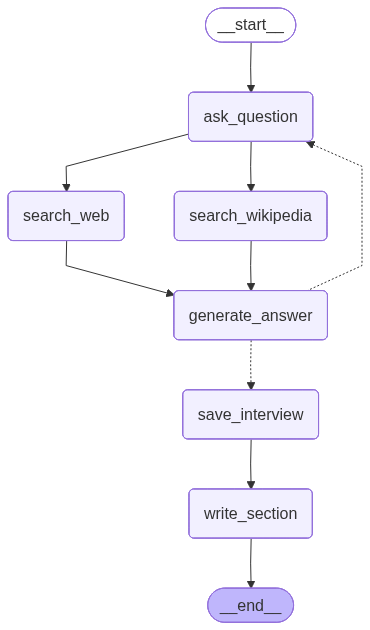

In [152]:
display(Image(interview_graph.get_graph().draw_mermaid_png()))


In [153]:
analyst

Analyst(name="Liam O'Connor", role='Enterprise Application Developer', affiliation='NextGen Software Solutions', description="Liam O'Connor is involved in the development of enterprise applications and is interested in how LangGraph can enhance application performance and scalability. He investigates the framework's potential to support complex, distributed systems and its ability to integrate seamlessly with existing enterprise software solutions.")

In [154]:
from IPython.display import Markdown

In [155]:
messages = [HumanMessage("So you said you were writing as article on langgraph?")]

In [156]:
thread = {"configurable":{"thread_id":1}}

In [162]:
interview = interview_graph.invoke({"analyst": analyst, "messages": messages, "max_num_turns": 2}, thread)


HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


*******************************
search_query='challenges integrating LangGraph with existing enterprise software solutions'


HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
Retrying request to /chat/completions in 0.475990 seconds
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
Retrying request to /chat/completions in 0.901975 seconds
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 429 Too Many Requests"


RateLimitError: Error code: 429 - {'error': {'message': 'Request too large for gpt-4o in organization org-eE3S4Hv0L6TBiSrX2PMqBqgj on tokens per min (TPM): Limit 30000, Requested 55963. The input or output tokens must be reduced in order to run successfully. Visit https://platform.openai.com/account/rate-limits to learn more.', 'type': 'tokens', 'param': None, 'code': 'rate_limit_exceeded'}}

In [163]:
Markdown(interview['sections'][0])

NameError: name 'interview' is not defined

### Third Workflow